### Now, we gonna do the statistical modeling after cleaning the dataset

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy import stats


In [3]:
# now, we've to load the dataset that we just cleaned in the previous notebook
df = pd.read_csv('diabetes_cleaned.csv')

# let's first just verify it's shape
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (95103, 14)
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current', 'smoking_unknown']


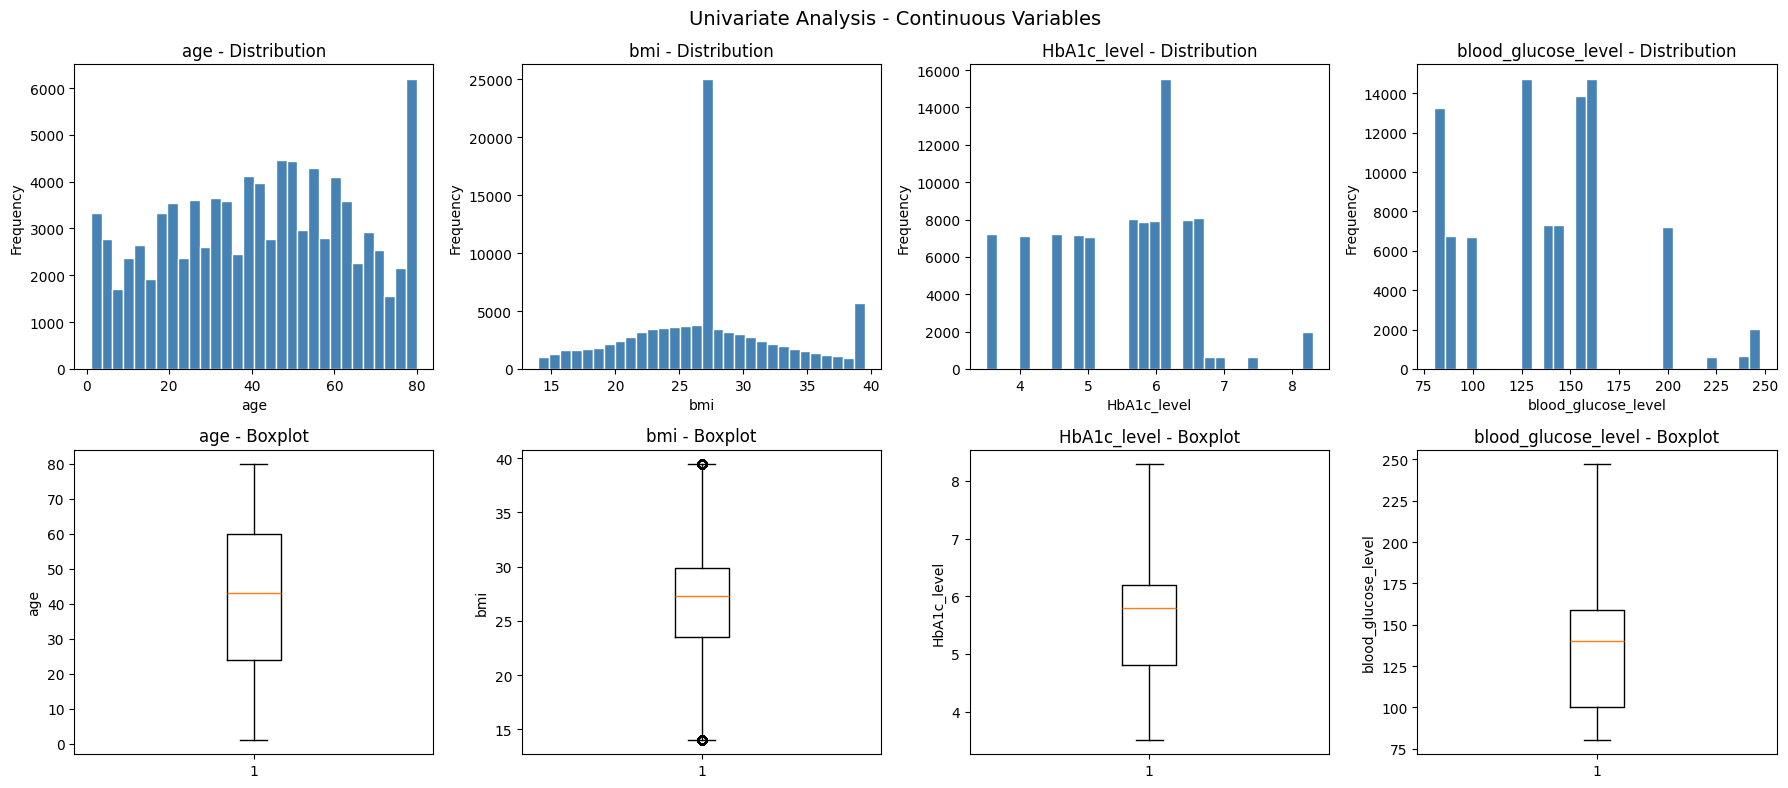

In [4]:
#now, here's some univariate analysis for continuous variables
continuous_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(continuous_cols):
    # Histogram + KDE
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} - Distribution')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    
    # Boxplot
    axes[1, i].boxplot(df[col])
    axes[1, i].set_title(f'{col} - Boxplot')
    axes[1, i].set_ylabel(col)

plt.suptitle('Univariate Analysis - Continuous Variables', fontsize=14)
plt.tight_layout()
plt.show()

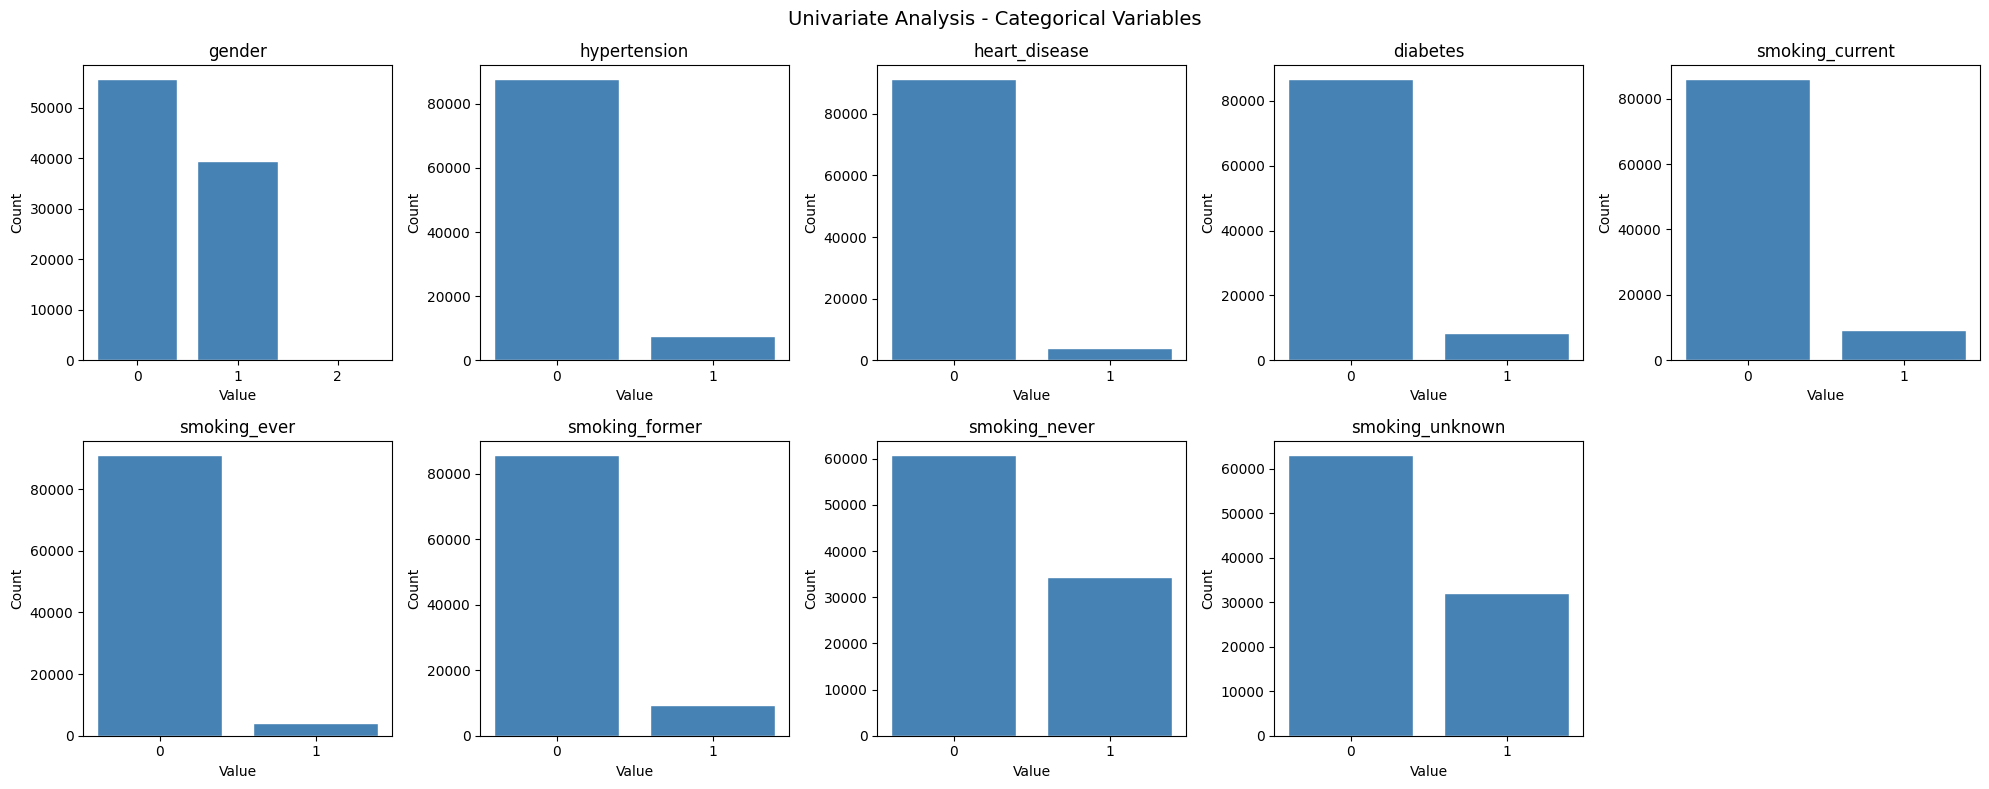

In [5]:
#now, categorical variables analysis
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'diabetes',
                    'smoking_current', 'smoking_ever', 'smoking_former',
                    'smoking_never', 'smoking_unknown']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the extra subplot
axes[-1].set_visible(False)

plt.suptitle('Univariate Analysis - Categorical Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
print("===== SUMMARY STATISTICS =====")
print(df[continuous_cols].describe().round(2))

===== SUMMARY STATISTICS =====
            age       bmi  HbA1c_level  blood_glucose_level
count  95103.00  95103.00     95103.00             95103.00
mean      42.19     27.11         5.53               137.56
std       22.21      5.84         1.05                38.66
min        1.00     13.98         3.50                80.00
25%       24.00     23.54         4.80               100.00
50%       43.00     27.32         5.80               140.00
75%       60.00     29.90         6.20               159.00
max       80.00     39.50         8.30               247.50


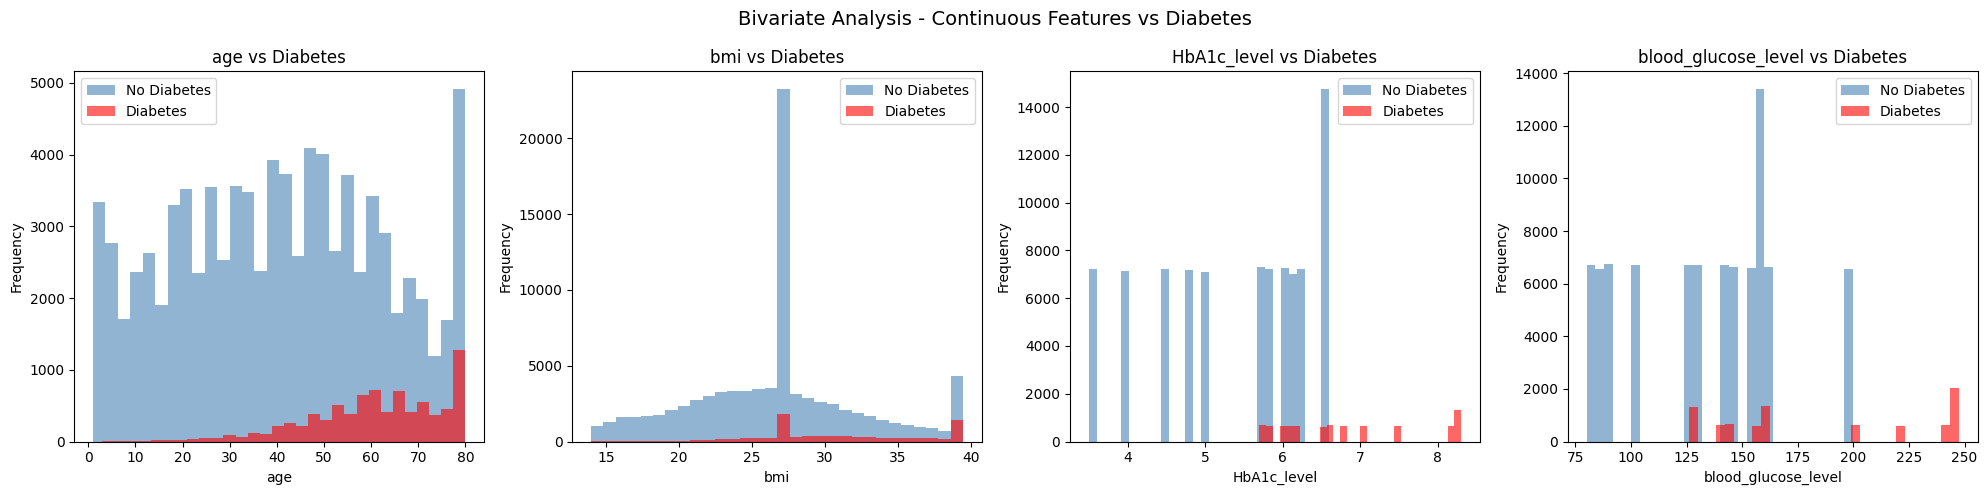

In [7]:
# now, we're gonna find the bivariate analysis
continuous_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(continuous_cols):
    diabetic = df[df['diabetes'] == 1][col]
    non_diabetic = df[df['diabetes'] == 0][col]
    
    axes[i].hist(non_diabetic, bins=30, alpha=0.6, color='steelblue', label='No Diabetes')
    axes[i].hist(diabetic, bins=30, alpha=0.6, color='red', label='Diabetes')
    axes[i].set_title(f'{col} vs Diabetes')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Bivariate Analysis - Continuous Features vs Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
print("===== MEAN VALUES BY DIABETES STATUS =====")
print(df.groupby('diabetes')[continuous_cols].mean().round(2))

===== MEAN VALUES BY DIABETES STATUS =====
            age    bmi  HbA1c_level  blood_glucose_level
diabetes                                                
0         40.36  26.72         5.40               132.82
1         60.91  31.05         6.84               186.08


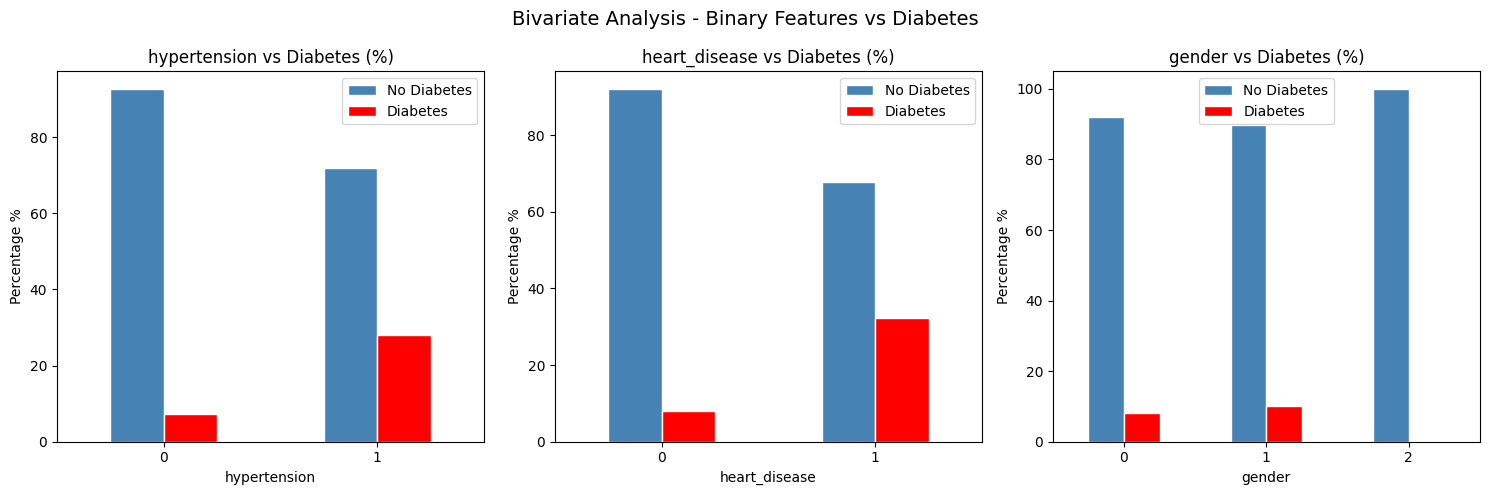

In [9]:
binary_cols = ['hypertension', 'heart_disease', 'gender']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(binary_cols):
    crosstab = pd.crosstab(df[col], df['diabetes'], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[i], color=['steelblue', 'red'], edgecolor='white')
    axes[i].set_title(f'{col} vs Diabetes (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage %')
    axes[i].legend(['No Diabetes', 'Diabetes'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Bivariate Analysis - Binary Features vs Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
corr_matrix = df.corr(numeric_only=True)
print("===== CORRELATION WITH DIABETES =====")
print(corr_matrix['diabetes'].sort_values(ascending=False).round(3))

===== CORRELATION WITH DIABETES =====
diabetes               1.000
blood_glucose_level    0.392
HbA1c_level            0.392
age                    0.263
bmi                    0.211
hypertension           0.195
heart_disease          0.170
smoking_former         0.095
gender                 0.039
smoking_ever           0.021
smoking_never          0.021
smoking_not current    0.018
smoking_current        0.016
smoking_unknown       -0.110
Name: diabetes, dtype: float64


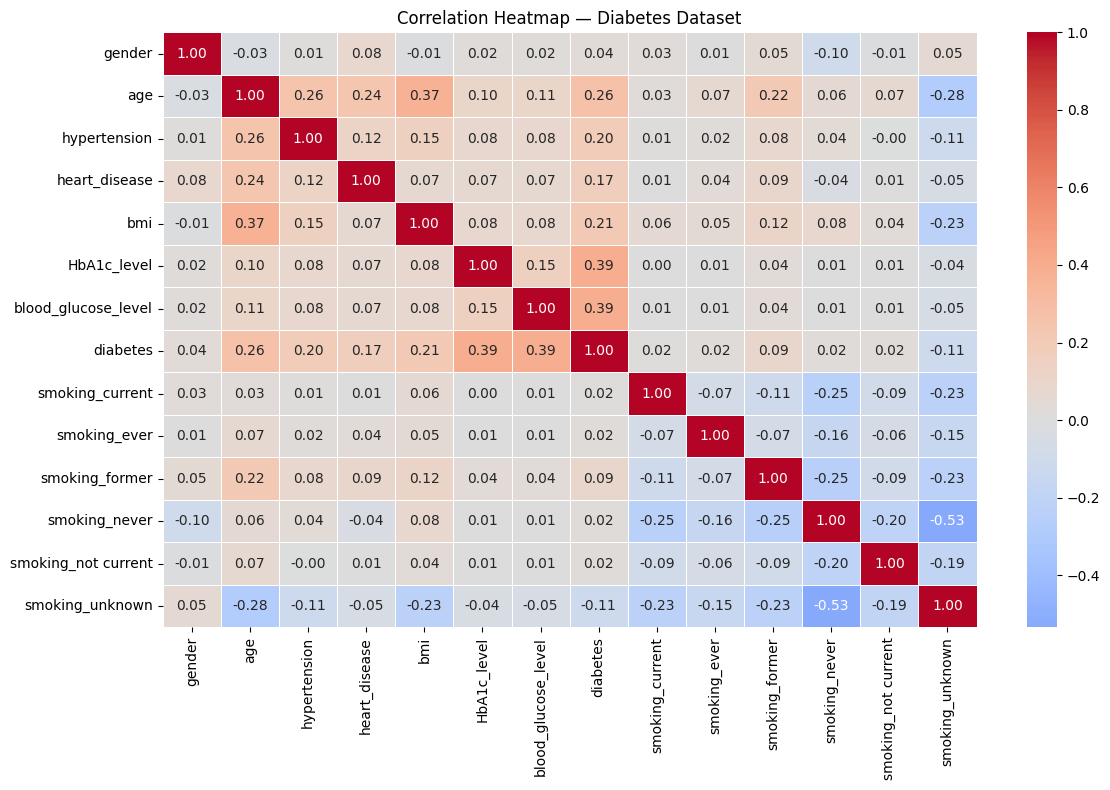

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — Diabetes Dataset')
plt.tight_layout()
plt.show()

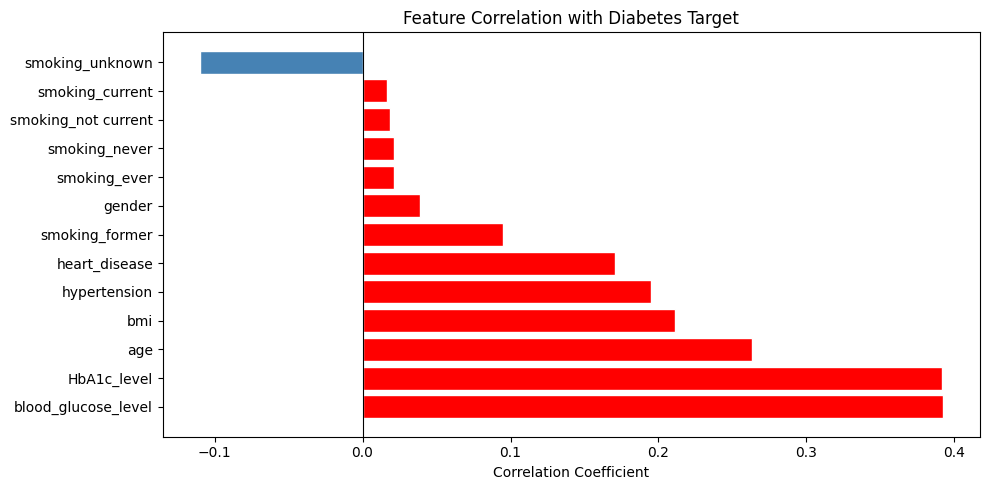

In [12]:
diabetes_corr = corr_matrix['diabetes'].drop('diabetes').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['red' if x > 0 else 'steelblue' for x in diabetes_corr]
plt.barh(diabetes_corr.index, diabetes_corr.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Diabetes Target')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [15]:
#now, we're gonna do the Statistical Testing
# let's do a t-test for the continuous variables
continuous_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print("===== INDEPENDENT T-TEST RESULTS =====")
print(f"{'Feature':<25} {'T-Statistic':>12} {'P-Value':>12} {'Significant':>12}")
print("-" * 65)

for col in continuous_cols:
    diabetic = df[df['diabetes'] == 1][col]
    non_diabetic = df[df['diabetes'] == 0][col]
    t_stat, p_value = stats.ttest_ind(diabetic, non_diabetic)
    significant = "YES" if p_value < 0.05 else "NO"
    print(f"{col:<25} {t_stat:>12.3f} {p_value:>12.6f} {significant:>12}")

===== INDEPENDENT T-TEST RESULTS =====
Feature                    T-Statistic      P-Value  Significant
-----------------------------------------------------------------
age                             84.235     0.000000          YES
bmi                             66.597     0.000000          YES
HbA1c_level                    131.309     0.000000          YES
blood_glucose_level            131.475     0.000000          YES


In [16]:
# now, let's do the CHI-SQUARE testing 
from scipy.stats import chi2_contingency

binary_cols = ['hypertension', 'heart_disease', 'gender']

print("\n===== CHI-SQUARE TEST RESULTS =====")
print(f"{'Feature':<25} {'Chi2-Statistic':>14} {'P-Value':>12} {'Significant':>12}")
print("-" * 67)

for col in binary_cols:
    contingency_table = pd.crosstab(df[col], df['diabetes'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    significant = "YES" if p_value < 0.05 else "NO"
    print(f"{col:<25} {chi2:>14.3f} {p_value:>12.6f} {significant:>12}")


===== CHI-SQUARE TEST RESULTS =====
Feature                   Chi2-Statistic      P-Value  Significant
-------------------------------------------------------------------
hypertension                    3623.724     0.000000          YES
heart_disease                   2756.476     0.000000          YES
gender                           145.663     0.000000          YES


In [17]:
# now, we've to do the feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Train a quick Random Forest just for importance ranking
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get importance scores
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("===== FEATURE IMPORTANCE RANKING =====")
print(importance_df.round(4))

===== FEATURE IMPORTANCE RANKING =====
                Feature  Importance
0           HbA1c_level      0.4011
1   blood_glucose_level      0.3320
2                   bmi      0.1113
3                   age      0.1059
4          hypertension      0.0135
5         heart_disease      0.0100
6                gender      0.0079
7         smoking_never      0.0038
8        smoking_former      0.0036
9       smoking_unknown      0.0036
10      smoking_current      0.0027
11  smoking_not current      0.0024
12         smoking_ever      0.0023


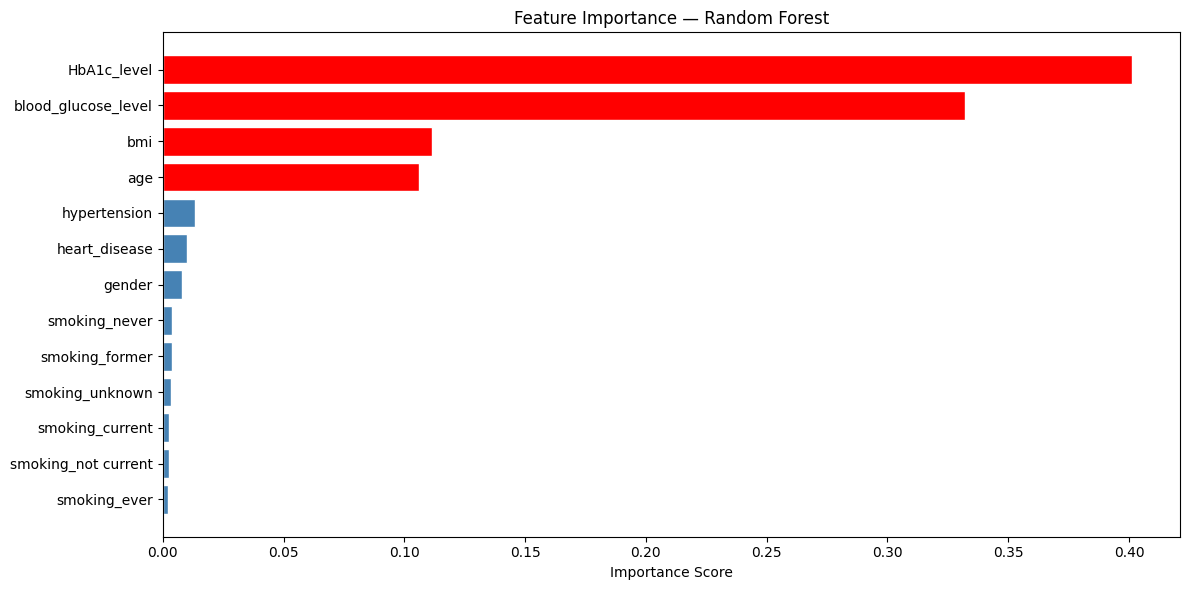

In [18]:
plt.figure(figsize=(12, 6))
colors = ['red' if i < 4 else 'steelblue' for i in range(len(importance_df))]
plt.barh(importance_df['Feature'][::-1], 
         importance_df['Importance'][::-1], 
         color=colors[::-1], edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()